In [1]:
# Check GPU
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import pandas as pd
import os

data_path = "/content/drive/MyDrive/amazon_sentiment"

train = pd.read_parquet(
    os.path.join(data_path, "amazon_train_processed.parquet")
)

test = pd.read_parquet(
    os.path.join(data_path, "amazon_test_processed.parquet")
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (3600000, 2)
Test shape: (400000, 2)


In [ ]:
print(train.head())
print()
print(train["label"].value_counts())

                                                text  label
0  stuning even for the non-gamer: this sound tra...      1
1  the best soundtrack ever to anything.: i'm rea...      1
2  amazing!: this soundtrack is my favorite music...      1
3  excellent soundtrack: i truly like this soundt...      1
4  remember, pull your jaw off the floor after he...      1

label
1    1800000
0    1800000
Name: count, dtype: int64


In [ ]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(train["label"].value_counts())
print(tf.config.list_physical_devices("GPU"))

Train shape: (3600000, 2)
Test shape: (400000, 2)
label
1    1800000
0    1800000
Name: count, dtype: int64
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
# Load the tokenizer we created earlier
from tensorflow.keras.preprocessing.text import tokenizer_from_json
import json

with open("/content/drive/MyDrive/amazon_sentiment/amazon_tokenizer.json", "r", encoding="utf-8") as f:
    tokenizer = tokenizer_from_json(f.read())

# Load project configuration
with open("/content/drive/MyDrive/amazon_sentiment/amazon_config.json", "r") as f:
    config = json.load(f)

vocab_size = config["vocab_size"]
max_sequence_length = config["max_sequence_length"]

print("Vocabulary size:", vocab_size)
print("Maximum sequence length:", max_sequence_length)

Vocabulary size: 30000
Maximum sequence length: 200


In [ ]:
# Use a balanced 500K subset for classical ML
train_ml = train.groupby("label", group_keys=False).sample(
    n=250000,
    random_state=42
)

print("Training samples:", len(train_ml))
print(train_ml["label"].value_counts())

Training samples: 500000
label
0    250000
1    250000
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert reviews into TF-IDF features
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train = tfidf.fit_transform(train_ml["text"])
y_train = train_ml["label"]

print("TF-IDF shape:", X_train.shape)

TF-IDF shape: (500000, 50000)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [ ]:
# Create a balanced 100K test sample
test_ml = test.groupby("label", group_keys=False).sample(
    n=50000,
    random_state=42
)

# Convert test reviews using the SAME TF-IDF vectorizer
X_test = tfidf.transform(test_ml["text"])
y_test = test_ml["label"]

# Make predictions
y_pred = lr_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)
print()
print(classification_report(y_test, y_pred))

Test Accuracy: 0.92998

              precision    recall  f1-score   support

           0       0.93      0.93      0.93     50000
           1       0.93      0.93      0.93     50000

    accuracy                           0.93    100000
   macro avg       0.93      0.93      0.93    100000
weighted avg       0.93      0.93      0.93    100000



In [ ]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

# Select the most informative TF-IDF features
selector = SelectKBest(chi2, k=5000)

X_train_xgb = selector.fit_transform(X_train, y_train)
X_test_xgb = selector.transform(X_test)

print("XGBoost training shape:", X_train_xgb.shape)
print("XGBoost test shape:", X_test_xgb.shape)

XGBoost training shape: (500000, 5000)
XGBoost test shape: (100000, 5000)


In [ ]:
# Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    random_state=42
)

xgb_model.fit(X_train_xgb, y_train)

print("XGBoost training completed.")

XGBoost training completed.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_xgb = xgb_model.predict(X_test_xgb)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print()
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: UserWarning: [23:33:07] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


XGBoost Accuracy: 0.88079

              precision    recall  f1-score   support

           0       0.89      0.87      0.88     50000
           1       0.88      0.89      0.88     50000

    accuracy                           0.88    100000
   macro avg       0.88      0.88      0.88    100000
weighted avg       0.88      0.88      0.88    100000



In [ ]:
# Create a balanced subset for deep learning experiments
train_dl = train.groupby("label", group_keys=False).sample(
    n=250000,
    random_state=42
)

print("Training samples:", len(train_dl))
print(train_dl["label"].value_counts())

Training samples: 500000
label
0    250000
1    250000
Name: count, dtype: int64


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Convert reviews into integer sequences
X_dl = tokenizer.texts_to_sequences(train_dl["text"])

# Pad/truncate all reviews to 200 tokens
X_dl = pad_sequences(
    X_dl,
    maxlen=max_sequence_length,
    padding="post",
    truncating="post"
)

y_dl = train_dl["label"].values

print("Input shape:", X_dl.shape)
print("Labels shape:", y_dl.shape)

Input shape: (500000, 200)
Labels shape: (500000,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# Build CNN model
cnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),

    Conv1D(filters=128, kernel_size=5, activation="relu"),
    GlobalMaxPooling1D(),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_cnn = cnn_model.fit(
    X_dl,
    y_dl,
    validation_split=0.1,
    epochs=5,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.9076 - loss: 0.2286 - val_accuracy: 0.9393 - val_loss: 0.1617
Epoch 2/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9541 - loss: 0.1310 - val_accuracy: 0.9192 - val_loss: 0.2203
Epoch 3/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9770 - loss: 0.0718 - val_accuracy: 0.9306 - val_loss: 0.2192


In [ ]:
# Convert test reviews into sequences
X_test_dl = tokenizer.texts_to_sequences(test_ml["text"])

X_test_dl = pad_sequences(
    X_test_dl,
    maxlen=max_sequence_length,
    padding="post",
    truncating="post"
)

print("Test input shape:", X_test_dl.shape)

Test input shape: (100000, 200)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Predict sentiment
y_pred_cnn_prob = cnn_model.predict(X_test_dl, batch_size=512)
y_pred_cnn = (y_pred_cnn_prob >= 0.5).astype(int).ravel()

print("CNN Accuracy:", accuracy_score(y_test, y_pred_cnn))
print()
print(classification_report(y_test, y_pred_cnn))

196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
CNN Accuracy: 0.9325

              precision    recall  f1-score   support

           0       0.94      0.93      0.93     50000
           1       0.93      0.94      0.93     50000

    accuracy                           0.93    100000
   macro avg       0.93      0.93      0.93    100000
weighted avg       0.93      0.93      0.93    100000



In [ ]:
# Create balanced 500K training data for LSTM
train_lstm = train.groupby("label", group_keys=False).sample(
    n=250000,
    random_state=42
)

# Shuffle so both classes are mixed
train_lstm = train_lstm.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Training shape:", train_lstm.shape)
print("\nLabel distribution:")
print(train_lstm["label"].value_counts())

Training shape: (500000, 2)

Label distribution:
label
0    250000
1    250000
Name: count, dtype: int64


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Convert reviews into integer sequences
X_lstm = tokenizer.texts_to_sequences(train_lstm["text"])

# Make all sequences the same length
X_lstm = pad_sequences(
    X_lstm,
    maxlen=max_sequence_length,
    padding="post",
    truncating="post"
)

y_lstm = train_lstm["label"].values

print("X shape:", X_lstm.shape)
print("y shape:", y_lstm.shape)

X shape: (500000, 200)
y shape: (500000,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout

# Build LSTM model
lstm_model = Sequential([
    Input(shape=(max_sequence_length,)),

    # Convert token IDs into dense word representations
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    # Learn sequential relationships between words
    LSTM(128),

    Dense(64, activation="relu"),
    Dropout(0.5),

    # Binary sentiment output
    Dense(1, activation="sigmoid")
])

# Compile the model
lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,979,905 (15.18 MB)

 Trainable params: 3,979,905 (15.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

# Train the LSTM
history_lstm = lstm_model.fit(
    X_lstm,
    y_lstm,
    validation_split=0.1,
    epochs=5,
    batch_size=256,
    shuffle=True,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 57s 28ms/step - accuracy: 0.4997 - loss: 0.6932 - val_accuracy: 0.5013 - val_loss: 0.6931
Epoch 2/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 51s 29ms/step - accuracy: 0.5006 - loss: 0.6932 - val_accuracy: 0.5014 - val_loss: 0.6932
Epoch 3/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 50s 29ms/step - accuracy: 0.4996 - loss: 0.6945 - val_accuracy: 0.5013 - val_loss: 0.6931
Epoch 4/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 53s 30ms/step - accuracy: 0.6181 - loss: 0.6217 - val_accuracy: 0.8386 - val_loss: 0.3928
Epoch 5/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 52s 30ms/step - accuracy: 0.9026 - loss: 0.2750 - val_accuracy: 0.9298 - val_loss: 0.1831


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Convert test reviews into sequences
X_test_lstm = tokenizer.texts_to_sequences(test_ml["text"])

X_test_lstm = pad_sequences(
    X_test_lstm,
    maxlen=max_sequence_length,
    padding="post",
    truncating="post"
)

y_test_lstm = test_ml["label"].values

# Predict sentiment
lstm_predictions = (lstm_model.predict(X_test_lstm, batch_size=256) > 0.5).astype(int).flatten()

# Calculate accuracy
lstm_accuracy = accuracy_score(y_test_lstm, lstm_predictions)

print(f"LSTM Test Accuracy: {lstm_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_lstm, lstm_predictions))

391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
LSTM Test Accuracy: 0.9304

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     50000
           1       0.94      0.92      0.93     50000

    accuracy                           0.93    100000
   macro avg       0.93      0.93      0.93    100000
weighted avg       0.93      0.93      0.93    100000



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout

# Build CNN-LSTM model
cnn_lstm_model = Sequential([
    Input(shape=(max_sequence_length,)),

    # Convert token IDs into word embeddings
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    # Extract important local word/phrase patterns
    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),

    # Reduce sequence size
    MaxPooling1D(pool_size=2),

    # Learn sequential relationships
    LSTM(128),

    Dense(64, activation="relu"),
    Dropout(0.5),

    # Binary sentiment output
    Dense(1, activation="sigmoid")
])

# Compile the model
cnn_lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 196, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 98, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,061,953 (15.50 MB)

 Trainable params: 4,061,953 (15.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop if validation performance stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

# Train CNN-LSTM
history_cnn_lstm = cnn_lstm_model.fit(
    X_lstm,
    y_lstm,
    validation_split=0.1,
    epochs=5,
    batch_size=256,
    shuffle=True,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.7928 - loss: 0.3835 - val_accuracy: 0.9260 - val_loss: 0.1898
Epoch 2/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 53s 30ms/step - accuracy: 0.9399 - loss: 0.1654 - val_accuracy: 0.9321 - val_loss: 0.1736
Epoch 3/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 54s 30ms/step - accuracy: 0.9597 - loss: 0.1191 - val_accuracy: 0.9349 - val_loss: 0.1748
Epoch 4/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 54s 31ms/step - accuracy: 0.9747 - loss: 0.0811 - val_accuracy: 0.9280 - val_loss: 0.2081


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Predict sentiment using CNN-LSTM
cnn_lstm_predictions = (
    cnn_lstm_model.predict(X_test_lstm, batch_size=256) > 0.5
).astype(int).flatten()

# Calculate accuracy
cnn_lstm_accuracy = accuracy_score(
    y_test_lstm,
    cnn_lstm_predictions
)

print(f"CNN-LSTM Test Accuracy: {cnn_lstm_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_lstm,
        cnn_lstm_predictions
    )
)

391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step
CNN-LSTM Test Accuracy: 0.9338

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93     50000
           1       0.92      0.95      0.94     50000

    accuracy                           0.93    100000
   macro avg       0.93      0.93      0.93    100000
weighted avg       0.93      0.93      0.93    100000



                 Model  Accuracy
0             CNN-LSTM   0.93380
1                  CNN   0.93194
2                 LSTM   0.93040
3  Logistic Regression   0.92998
4              XGBoost   0.88079


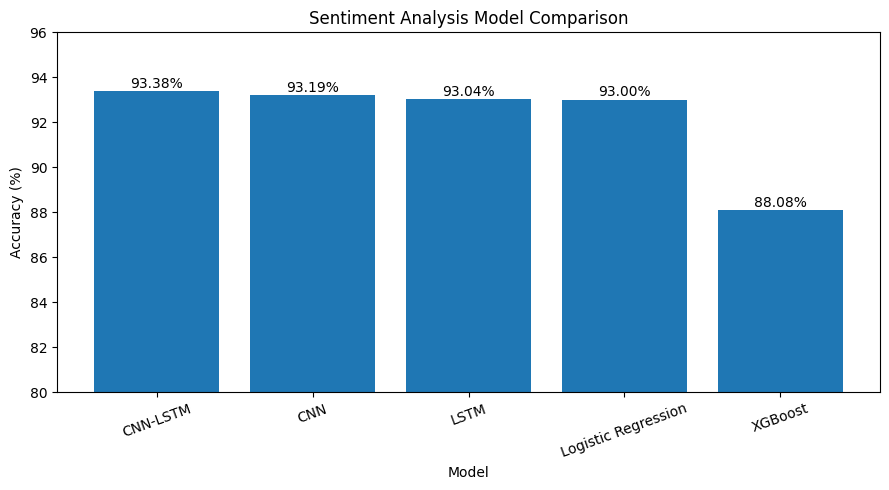

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Model accuracy results
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "CNN",
        "LSTM",
        "CNN-LSTM"
    ],
    "Accuracy": [
        0.92998,
        0.88079,
        0.93194,
        0.93040,
        0.93380
    ]
})

# Sort from highest to lowest accuracy
results = results.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

# Display numerical results
print(results)

# Plot comparison
plt.figure(figsize=(9, 5))

bars = plt.bar(
    results["Model"],
    results["Accuracy"] * 100
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Sentiment Analysis Model Comparison")
plt.ylim(80, 96)

plt.xticks(rotation=20)

# Show accuracy value on each bar
for bar, accuracy in zip(bars, results["Accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{accuracy * 100:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [3]:
import tensorflow as tf

# Use the full 3.6M training reviews
texts = train["text"].values
labels = train["label"].values

# Create TensorFlow dataset
full_dataset = tf.data.Dataset.from_tensor_slices((texts, labels))

# Shuffle the complete training data
full_dataset = full_dataset.shuffle(
    buffer_size=100000,
    seed=42
)

# Process data in batches
full_dataset = full_dataset.batch(256)

print("Full training dataset ready")

Full training dataset ready


In [4]:
def preprocess_batch(text_batch, label_batch):
    # Convert text to integer sequences
    sequences = tokenizer.texts_to_sequences(
        text_batch.numpy()
    )

    # Pad sequences
    sequences = pad_sequences(
        sequences,
        maxlen=max_sequence_length,
        padding="post",
        truncating="post"
    )

    return sequences, label_batch.numpy()

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout

# Recreate the CNN-LSTM model
cnn_lstm_model = Sequential([
    Input(shape=(max_sequence_length,)),

    # Word embeddings
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    # Extract local features
    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),

    # Reduce sequence length
    MaxPooling1D(pool_size=2),

    # Learn sequential relationships
    LSTM(128),

    Dense(64, activation="relu"),
    Dropout(0.5),

    # Sentiment output
    Dense(1, activation="sigmoid")
])

cnn_lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 98, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,061,953 (15.50 MB)

 Trainable params: 4,061,953 (15.50 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
import numpy as np
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences

class ReviewSequence(Sequence):

    def __init__(self, texts, labels, batch_size=256, shuffle=True):
        self.texts = texts
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(texts))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.texts) / self.batch_size))

    def __getitem__(self, index):
        # Get indexes for this batch
        batch_indexes = self.indexes[
            index * self.batch_size:
            (index + 1) * self.batch_size
        ]

        # Get reviews and labels
        batch_texts = self.texts[batch_indexes]
        batch_labels = self.labels[batch_indexes]

        # Convert text to token sequences
        sequences = tokenizer.texts_to_sequences(batch_texts)

        # Pad sequences
        sequences = pad_sequences(
            sequences,
            maxlen=max_sequence_length,
            padding="post",
            truncating="post"
        )

        return sequences, batch_labels

    def on_epoch_end(self):
        # Shuffle after every epoch
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [9]:
# Convert to NumPy arrays
texts = train["text"].values
labels = train["label"].values

# Shuffle the complete dataset once
np.random.seed(42)
indexes = np.random.permutation(len(texts))

texts = texts[indexes]
labels = labels[indexes]

# Split 90% training / 10% validation
split = int(0.9 * len(texts))

train_texts = texts[:split]
train_labels = labels[:split]

val_texts = texts[split:]
val_labels = labels[split:]

print("Training reviews:", len(train_texts))
print("Validation reviews:", len(val_texts))

Training reviews: 3240000
Validation reviews: 360000


In [10]:
# Create batch generators
train_generator = ReviewSequence(
    train_texts,
    train_labels,
    batch_size=256,
    shuffle=True
)

val_generator = ReviewSequence(
    val_texts,
    val_labels,
    batch_size=256,
    shuffle=False
)

print("Training batches:", len(train_generator))
print("Validation batches:", len(val_generator))

Training batches: 12657
Validation batches: 1407


In [11]:
# Test one batch
X_batch, y_batch = train_generator[0]

print("Batch X shape:", X_batch.shape)
print("Batch y shape:", y_batch.shape)
print("First 10 labels:", y_batch[:10])

Batch X shape: (256, 200)
Batch y shape: (256,)
First 10 labels: [0 0 0 1 1 0 0 0 0 1]


In [12]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop if validation loss stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

# Train CNN-LSTM on the full training data
history_full = cnn_lstm_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stopping],
    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
12657/12657 ━━━━━━━━━━━━━━━━━━━━ 432s 34ms/step - accuracy: 0.8293 - loss: 0.3032 - val_accuracy: 0.9501 - val_loss: 0.1332
Epoch 2/5
12657/12657 ━━━━━━━━━━━━━━━━━━━━ 428s 34ms/step - accuracy: 0.9558 - loss: 0.1245 - val_accuracy: 0.9526 - val_loss: 0.1285
Epoch 3/5
12657/12657 ━━━━━━━━━━━━━━━━━━━━ 439s 34ms/step - accuracy: 0.9649 - loss: 0.1021 - val_accuracy: 0.9541 - val_loss: 0.1282
Epoch 4/5
12657/12657 ━━━━━━━━━━━━━━━━━━━━ 437s 35ms/step - accuracy: 0.9726 - loss: 0.0827 - val_accuracy: 0.9522 - val_loss: 0.1384
Epoch 5/5
12657/12657 ━━━━━━━━━━━━━━━━━━━━ 435s 34ms/step - accuracy: 0.9786 - loss: 0.0668 - val_accuracy: 0.9509 - val_loss: 0.1536


In [14]:
# Recreate the same 100K development test set
test_ml = test.groupby(
    "label",
    group_keys=False
).sample(
    n=50000,
    random_state=42
)

print("Development test shape:", test_ml.shape)
print(test_ml["label"].value_counts())

Development test shape: (100000, 2)
label
0    50000
1    50000
Name: count, dtype: int64


In [15]:
# Remove the 100K development reviews
# The remaining 300K are our untouched final test set
final_test = test.drop(test_ml.index)

print("Final test shape:", final_test.shape)
print("\nLabel distribution:")
print(final_test["label"].value_counts())

Final test shape: (300000, 2)

Label distribution:
label
1    150000
0    150000
Name: count, dtype: int64


In [16]:
# Create generator for the untouched 300K test reviews
final_test_generator = ReviewSequence(
    final_test["text"].values,
    final_test["label"].values,
    batch_size=256,
    shuffle=False
)

print("Final test batches:", len(final_test_generator))

Final test batches: 1172


In [17]:
# Predict sentiment on the untouched 300K test reviews
final_predictions = (
    cnn_lstm_model.predict(
        final_test_generator,
        verbose=1
    ) > 0.5
).astype(int).flatten()

final_actual = final_test["label"].values

print("Predictions completed")
print("Number of predictions:", len(final_predictions))

1172/1172 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step
Predictions completed
Number of predictions: 300000


In [18]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate final accuracy
final_accuracy = accuracy_score(
    final_actual,
    final_predictions
)

print(f"Final Test Accuracy: {final_accuracy:.4f}")
print(f"Final Test Accuracy: {final_accuracy * 100:.2f}%")

# Detailed performance
print("\nClassification Report:")
print(
    classification_report(
        final_actual,
        final_predictions,
        target_names=["Negative", "Positive"]
    )
)

Final Test Accuracy: 0.9535
Final Test Accuracy: 95.35%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.96      0.95    150000
    Positive       0.96      0.95      0.95    150000

    accuracy                           0.95    300000
   macro avg       0.95      0.95      0.95    300000
weighted avg       0.95      0.95      0.95    300000



Confusion Matrix:
[[143764   6236]
 [  7710 142290]]


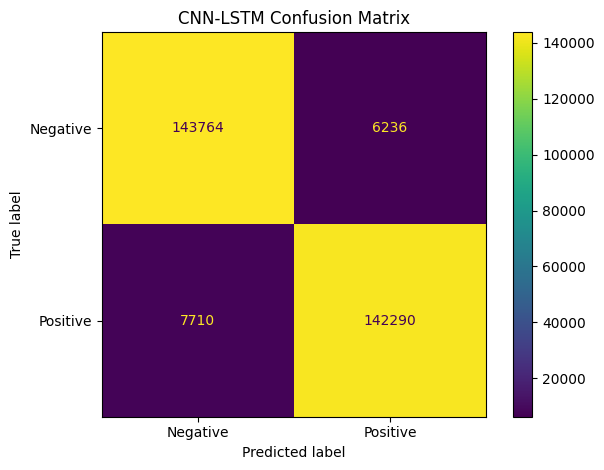

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm = confusion_matrix(
    final_actual,
    final_predictions
)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("CNN-LSTM Confusion Matrix")
plt.tight_layout()
plt.show()

In [20]:
# Create error analysis dataframe
error_analysis = final_test.copy()

error_analysis["actual"] = final_actual
error_analysis["predicted"] = final_predictions

# Keep only incorrect predictions
errors = error_analysis[
    error_analysis["actual"] != error_analysis["predicted"]
].copy()

# Convert labels to readable form
errors["actual_sentiment"] = errors["actual"].map({
    0: "Negative",
    1: "Positive"
})

errors["predicted_sentiment"] = errors["predicted"].map({
    0: "Negative",
    1: "Positive"
})

print("Total test reviews:", len(final_test))
print("Incorrect predictions:", len(errors))
print("Error rate:", f"{len(errors) / len(final_test) * 100:.2f}%")

Total test reviews: 300000
Incorrect predictions: 13946
Error rate: 4.65%


In [21]:
# Show 10 incorrectly classified reviews
errors[
    ["text", "actual_sentiment", "predicted_sentiment"]
].head(10)

,text,actual_sentiment,predicted_sentiment
3,"works fine, but maha energy is better: check o...",Positive,Negative
51,great beginning...poor ending: parricia corwel...,Positive,Negative
63,a historical gem whose title obscures its inte...,Negative,Positive
81,i would sell it -- book complete with dust cov...,Positive,Negative
89,a book for those with time on their hands: if ...,Negative,Positive
94,"the ""scarlet"" letter: much to my amazement, th...",Positive,Negative
122,there is no way anyone with a soul could ever ...,Positive,Negative
185,biography of wright and his works: easy readin...,Negative,Positive
191,a carefully constructed read.: this book is st...,Positive,Negative
253,worst night world book: this is the worst book...,Positive,Negative


In [22]:
# Save the final CNN-LSTM model
cnn_lstm_model.save(
    "/content/drive/MyDrive/amazon_sentiment/cnn_lstm_final.keras"
)

print("Final model saved successfully!")

Final model saved successfully!


In [23]:
import json

# Save tokenizer
with open(
    "/content/drive/MyDrive/amazon_sentiment/amazon_tokenizer.json",
    "w",
    encoding="utf-8"
) as f:
    f.write(tokenizer.to_json())

# Save model configuration
config = {
    "vocab_size": vocab_size,
    "max_sequence_length": max_sequence_length
}

with open(
    "/content/drive/MyDrive/amazon_sentiment/amazon_config.json",
    "w"
) as f:
    json.dump(config, f, indent=4)

print("Tokenizer and configuration saved!")

Tokenizer and configuration saved!
